# Phase 3 — GOE Spacing Statistics (Experiment 2)

**Goal:** subject the noise-band eigenvalues to a *finer* test than the density. The MP law
constrains where eigenvalues live on average; **level-spacing statistics** probe the local
correlations between neighboring eigenvalues. Random-matrix universality predicts that a
noise bulk shows *level repulsion* following the Gaussian Orthogonal Ensemble (GOE),
approximated by the Wigner surmise; eigenvalues carrying independent, uncorrelated
structure would instead show Poisson spacings. This is the paper's **Section 5.2** and
its second figure — the layer that distinguishes this study from an MP-only replication.

## The two competing predictions (for unfolded spacings $s$, mean 1)

$$P_{\mathrm{Wigner}}(s) = \frac{\pi s}{2} e^{-\pi s^2/4}
\qquad\text{vs.}\qquad
P_{\mathrm{Poisson}}(s) = e^{-s}$$

with CDFs $F_W(s) = 1 - e^{-\pi s^2/4}$ and $F_P(s) = 1 - e^{-s}$. The qualitative
difference is at $s \to 0$: repulsion ($P \to 0$) vs. clustering ($P \to 1$).

## Three methodological safeguards

1. **Unfolding.** Raw spacings mix the local fluctuations we care about with the smooth
   density variation across the band. We *unfold* through the fitted MP CDF from Phase 2,
   $x_i = n\,F_{\mathrm{MP}}(\lambda_i;\hat\sigma^2)$, giving mean spacing 1 by
   construction. Because unfolding choice is a classic source of artifacts, we repeat the
   analysis with a nonparametric unfolding (monotone PCHIP through the decimated
   spectral staircase) — agreement between the two rules out unfolding artifacts.
2. **A statistic that needs no unfolding.** The spacing-ratio statistic
   $\tilde r_i = \min(s_i, s_{i+1})/\max(s_i, s_{i+1})$ (Oganesyan–Huse) is invariant to
   the local density scale, so it bypasses both the unfolding and the $\sigma^2$
   ambiguity entirely. GOE and Poisson predict different distributions and means
   ($\langle\tilde r\rangle \approx 0.53$ vs. $2\ln 2 - 1 \approx 0.386$); we take the
   theoretical curves (Atas et al. surmise) with numerically verified normalization.
3. **Monte Carlo calibration, as in Phase 2.** Even a *true* Wishart noise bulk does not
   follow the Wigner surmise exactly (the surmise is the $2\times 2$ result, and edge
   effects distort finite spectra), so naive KS p-values are again the wrong yardstick.
   We recompute every statistic on simulated noise, running the *identical* pipeline per
   draw — spectrum, $\sigma^2$ re-fit, band selection, unfolding — and compare the
   observed values against those null distributions.

In [1]:
from pathlib import Path
import json, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.stats import kstwo

DATA_DIR = Path("data")
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9"]
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "font.size": 10, "axes.titlesize": 11,
})

ev = np.load(DATA_DIR / "eigen_phase1.npz", allow_pickle=True)
lam = ev["lam"][::-1].copy()          # ascending now (convenient for spacings)
q, T, N = float(ev["q"]), int(ev["T"]), int(ev["N"])
fit = json.loads((DATA_DIR / "mp_fit_results.json").read_text())
s2_fit = fit["sigma2_fit"]; lo_fit, hi_fit = fit["band_fit"]
s2_mkt = fit["sigma2_market"]; lo_mkt, hi_mkt = fit["band_market"]
Rs = pd.read_parquet(DATA_DIR / "returns_std.parquet").values
print(f"N={N}, T={T}, q={q:.4f}; fitted band [{lo_fit:.3f}, {hi_fit:.3f}] "
      f"(sigma2={s2_fit}), market band [{lo_mkt:.3f}, {hi_mkt:.3f}] (sigma2={s2_mkt})")

S2_GRID = np.arange(0.40, 1.1005, 0.002)

def mp_edges(s2):
    sq = np.sqrt(q)
    return s2 * (1 - sq)**2, s2 * (1 + sq)**2

def mp_cdf_grid(s2, npts=3000):
    lo, hi = mp_edges(s2)
    x = np.linspace(lo, hi, npts)
    with np.errstate(invalid="ignore"):
        pdf = np.sqrt(np.maximum((hi - x) * (x - lo), 0)) / (2 * np.pi * q * s2 * x)
    cdf = np.concatenate([[0], np.cumsum((pdf[1:] + pdf[:-1]) * np.diff(x) / 2)])
    return x, cdf / cdf[-1]

def ks_bulk_dist(evals, s2):
    lo, hi = mp_edges(s2)
    b = np.sort(evals[evals <= hi])
    n = len(b)
    if n < 10:
        return np.inf
    x, cdf = mp_cdf_grid(s2, npts=1500)
    F = np.interp(b, x, cdf, left=0.0, right=1.0)
    i = np.arange(1, n + 1)
    return max(np.max(i / n - F), np.max(F - (i - 1) / n))

def fit_sigma2(evals):
    Ds = np.array([ks_bulk_dist(evals, s2) for s2 in S2_GRID])
    j = int(np.argmin(Ds))
    return S2_GRID[j], Ds[j]

def ks_stat(sample, cdf_fn):
    x = np.sort(sample); n = len(x)
    F = cdf_fn(x); i = np.arange(1, n + 1)
    return max(np.max(i / n - F), np.max(F - (i - 1) / n))

F_wigner = lambda s: 1 - np.exp(-np.pi * s**2 / 4)
F_poisson = lambda s: 1 - np.exp(-s)

N=548, T=1236, q=0.4434; fitted band [0.063, 1.554] (sigma2=0.56), market band [0.085, 2.116] (sigma2=0.762344)


## 1. Unfold the bulk and compute the statistics

Both unfoldings, both bands, plus the unfolding-free ratio statistic. The PCHIP unfolding
fits a monotone smooth curve through every 15th point of the spectral staircase
$(\lambda_{(i)}, i)$ — enough knots to track the density, too few to absorb the
fluctuations under study.

In [2]:
def unfold_mp(bulk, s2):
    x, cdf = mp_cdf_grid(s2)
    return len(bulk) * np.interp(bulk, x, cdf, left=0.0, right=1.0)

def unfold_pchip(bulk, k=15):
    n = len(bulk)
    idx = np.arange(1, n + 1, dtype=float)
    knots = list(range(0, n - 1, k)) + [n - 1]
    f = PchipInterpolator(bulk[knots], idx[knots])
    return f(bulk)

def spacings(x):
    s = np.diff(x)
    return s / s.mean()

def ratio_stat(bulk):
    d = np.diff(bulk)                       # raw spacings: no unfolding needed
    r = np.minimum(d[:-1], d[1:]) / np.maximum(d[:-1], d[1:])
    return r

results = {}
for name, (lo, hi, s2) in {"fitted": (lo_fit, hi_fit, s2_fit),
                           "market": (lo_mkt, hi_mkt, s2_mkt)}.items():
    bulk = lam[(lam >= lo) & (lam <= hi)]
    s_mp = spacings(unfold_mp(bulk, s2))
    s_pc = spacings(unfold_pchip(bulk))
    r = ratio_stat(bulk)
    res = {"n_bulk": len(bulk),
           "D_wigner_mp": ks_stat(s_mp, F_wigner), "D_poisson_mp": ks_stat(s_mp, F_poisson),
           "D_wigner_pchip": ks_stat(s_pc, F_wigner), "D_poisson_pchip": ks_stat(s_pc, F_poisson),
           "r_mean": r.mean(), "n_ratios": len(r)}
    # edge-trim robustness: drop 10 spacings at each end
    res["D_wigner_mp_trim"] = ks_stat(s_mp[10:-10] / s_mp[10:-10].mean(), F_wigner)
    results[name] = res
    print(f"[{name} band] n={res['n_bulk']}  "
          f"D_wigner: MP-unfold {res['D_wigner_mp']:.4f} / PCHIP {res['D_wigner_pchip']:.4f} "
          f"(trimmed {res['D_wigner_mp_trim']:.4f})   "
          f"D_poisson: {res['D_poisson_mp']:.4f}   <r~> = {res['r_mean']:.4f}")

bulk_f = lam[(lam >= lo_fit) & (lam <= hi_fit)]
s_obs = spacings(unfold_mp(bulk_f, s2_fit))
r_obs = ratio_stat(bulk_f)
n_s, n_r = len(s_obs), len(r_obs)
print(f"\nprimary (fitted band): {n_s} spacings, {n_r} ratios; mean spacing {s_obs.mean():.3f}")
print(f"reference means: <r~>_GOE ~ 0.53 (calibrated below), <r~>_Poisson = 2ln2-1 = {2*np.log(2)-1:.4f}")

[fitted band] n=486  D_wigner: MP-unfold 0.0272 / PCHIP 0.0293 (trimmed 0.0238)   D_poisson: 0.2086   <r~> = 0.5362
[market band] n=506  D_wigner: MP-unfold 0.0432 / PCHIP 0.0292 (trimmed 0.0322)   D_poisson: 0.1878   <r~> = 0.5307

primary (fitted band): 485 spacings, 484 ratios; mean spacing 1.000
reference means: <r~>_GOE ~ 0.53 (calibrated below), <r~>_Poisson = 2ln2-1 = 0.3863


In [3]:
# surmise densities, normalized numerically on their supports (guards against
# constant-memory errors; any residual normalization error is corrected here)
rg = np.linspace(0, 1, 2001)
goe_ratio_raw = (rg + rg**2) / (1 + rg + rg**2)**2.5
goe_ratio = goe_ratio_raw / np.trapz(goe_ratio_raw, rg)
poi_ratio_raw = 2.0 / (1 + rg)**2
poi_ratio = poi_ratio_raw / np.trapz(poi_ratio_raw, rg)
r_mean_goe_surmise = np.trapz(rg * goe_ratio, rg)
r_mean_poi = np.trapz(rg * poi_ratio, rg)
print(f"surmise means: GOE {r_mean_goe_surmise:.4f}, Poisson {r_mean_poi:.4f}")

surmise means: GOE 0.5359, Poisson 0.3863


## 2. Monte Carlo calibration

$M = 200$ Gaussian–Wishart draws and $M = 200$ column-permutations of the real returns.
Each draw runs the full pipeline: spectrum $\to$ re-fit $\hat\sigma^2$ $\to$ its own bulk
$\to$ MP-CDF unfolding $\to$ $D_{\mathrm{Wigner}}$ and $\langle\tilde r\rangle$. The null
distributions answer: *how Wigner-like does genuine noise actually look at our exact
dimensions and with our exact procedure?*

In [4]:
rng = np.random.default_rng(43)
M = 200

def pipeline_stats(evals_asc):
    s2, _ = fit_sigma2(evals_asc)
    lo, hi = mp_edges(s2)
    b = evals_asc[(evals_asc >= lo) & (evals_asc <= hi)]
    s = spacings(unfold_mp(b, s2))
    r = ratio_stat(b)
    return ks_stat(s, F_wigner), r.mean()

def spectrum_of(X):
    Xs = (X - X.mean(0)) / X.std(0, ddof=0)
    return np.linalg.eigvalsh((Xs.T @ Xs) / X.shape[0])

t0 = time.time()
Dw_gauss, rm_gauss = np.empty(M), np.empty(M)
for m in range(M):
    Dw_gauss[m], rm_gauss[m] = pipeline_stats(spectrum_of(rng.standard_normal((T, N))))
print(f"Gaussian-Wishart null: {time.time()-t0:.0f}s")

t0 = time.time()
Dw_perm, rm_perm = np.empty(M), np.empty(M)
for m in range(M):
    Rp = np.column_stack([rng.permutation(Rs[:, j]) for j in range(N)])
    Dw_perm[m], rm_perm[m] = pipeline_stats(spectrum_of(Rp))
print(f"permutation null: {time.time()-t0:.0f}s")

D_obs = results["fitted"]["D_wigner_mp"]
r_obs_mean = results["fitted"]["r_mean"]
p_D_gauss = (1 + (Dw_gauss >= D_obs).sum()) / (M + 1)
p_D_perm  = (1 + (Dw_perm  >= D_obs).sum()) / (M + 1)
# two-sided for the ratio mean (deviation in either direction counts)
p_r_gauss = (1 + (np.abs(rm_gauss - rm_gauss.mean()) >= abs(r_obs_mean - rm_gauss.mean())).sum()) / (M + 1)
p_r_perm  = (1 + (np.abs(rm_perm - rm_perm.mean())  >= abs(r_obs_mean - rm_perm.mean())).sum())  / (M + 1)

print(f"\nD_Wigner observed = {D_obs:.4f}")
print(f"  null (Gaussian): median {np.median(Dw_gauss):.4f}, 95th {np.quantile(Dw_gauss, .95):.4f}  -> p = {p_D_gauss:.3f}")
print(f"  null (permuted): median {np.median(Dw_perm):.4f}, 95th {np.quantile(Dw_perm, .95):.4f}  -> p = {p_D_perm:.3f}")
print(f"\n<r~> observed = {r_obs_mean:.4f}")
print(f"  null (Gaussian): {rm_gauss.mean():.4f} +/- {rm_gauss.std():.4f}  -> two-sided p = {p_r_gauss:.3f}")
print(f"  null (permuted): {rm_perm.mean():.4f} +/- {rm_perm.std():.4f}  -> two-sided p = {p_r_perm:.3f}")
print(f"  (Poisson would give {r_mean_poi:.4f} -- "
      f"{abs(r_obs_mean - r_mean_poi)/rm_gauss.std():.0f} null-sigmas away)")

D_poi = results["fitted"]["D_poisson_mp"]
print(f"\nPoisson alternative: D = {D_poi:.4f}, naive p = {kstwo.sf(D_poi, n_s):.2e} -- "
      f"rejected at any level under any calibration")

Gaussian-Wishart null: 24s
permutation null: 29s

D_Wigner observed = 0.0272
  null (Gaussian): median 0.0289, 95th 0.0442  -> p = 0.612
  null (permuted): median 0.0287, 95th 0.0454  -> p = 0.572

<r~> observed = 0.5362
  null (Gaussian): 0.5309 +/- 0.0138  -> two-sided p = 0.776
  null (permuted): 0.5323 +/- 0.0126  -> two-sided p = 0.766
  (Poisson would give 0.3863 -- 11 null-sigmas away)

Poisson alternative: D = 0.2086, naive p = 5.52e-19 -- rejected at any level under any calibration


## 3. Figure 2 — spacing distribution and ratio statistic

Panel (a): unfolded nearest-neighbor spacing distribution against Wigner and Poisson.
Panel (b): the unfolding-free ratio statistic against both surmises — the same verdict
with none of the unfolding machinery, which is the point.

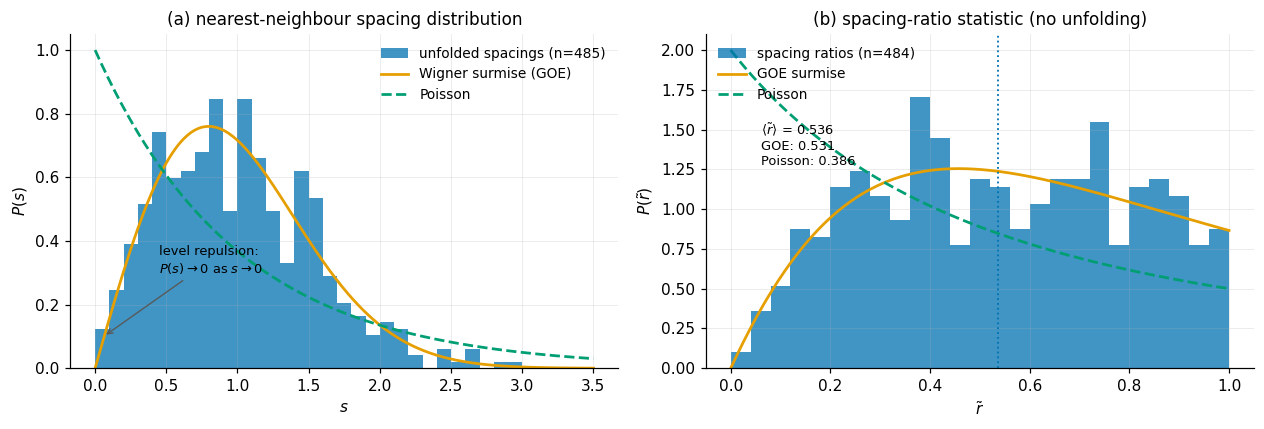

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.0))

bins_s = np.linspace(0, 3.5, 36)
axes[0].hist(s_obs, bins=bins_s, density=True, color=PALETTE[0], alpha=0.75,
             label=f"unfolded spacings (n={n_s})")
sg = np.linspace(0, 3.5, 400)
axes[0].plot(sg, np.pi * sg / 2 * np.exp(-np.pi * sg**2 / 4), color=PALETTE[1], lw=1.8,
             label="Wigner surmise (GOE)")
axes[0].plot(sg, np.exp(-sg), color=PALETTE[2], lw=1.8, ls="--", label="Poisson")
axes[0].set_xlabel("$s$"); axes[0].set_ylabel("$P(s)$")
axes[0].set_title("(a) nearest-neighbour spacing distribution")
axes[0].legend(frameon=False, fontsize=9)
axes[0].annotate("level repulsion:\n$P(s)\\to 0$ as $s\\to 0$", xy=(0.06, 0.10),
                 xytext=(0.45, 0.30), fontsize=8.5,
                 arrowprops=dict(arrowstyle="->", color="0.35", lw=0.9))

bins_r = np.linspace(0, 1, 26)
axes[1].hist(r_obs, bins=bins_r, density=True, color=PALETTE[0], alpha=0.75,
             label=f"spacing ratios (n={n_r})")
axes[1].plot(rg, goe_ratio, color=PALETTE[1], lw=1.8, label="GOE surmise")
axes[1].plot(rg, poi_ratio, color=PALETTE[2], lw=1.8, ls="--", label="Poisson")
axes[1].axvline(r_obs_mean, color=PALETTE[0], lw=1.2, ls=":")
axes[1].annotate(f"$\\langle\\tilde r\\rangle$ = {r_obs_mean:.3f}\n"
                 f"GOE: {rm_gauss.mean():.3f}\nPoisson: {r_mean_poi:.3f}",
                 xy=(r_obs_mean, 1.55), xytext=(0.06, 1.28), fontsize=8.5)
axes[1].set_xlabel("$\\tilde r$"); axes[1].set_ylabel("$P(\\tilde r)$")
axes[1].set_title("(b) spacing-ratio statistic (no unfolding)")
axes[1].legend(frameon=False, fontsize=9, loc="upper left")

fig.tight_layout()
fig.savefig(DATA_DIR / "fig_phase3_spacing.png", dpi=200, bbox_inches="tight")
plt.show()

In [6]:
out = {
    "band_used": "fitted", "n_bulk": int(results["fitted"]["n_bulk"]),
    "n_spacings": int(n_s), "n_ratios": int(n_r),
    "D_wigner_mp": round(float(D_obs), 6),
    "D_wigner_pchip": round(float(results["fitted"]["D_wigner_pchip"]), 6),
    "D_wigner_mp_trimmed": round(float(results["fitted"]["D_wigner_mp_trim"]), 6),
    "D_poisson": round(float(D_poi), 6),
    "D_wigner_market_band": round(float(results["market"]["D_wigner_mp"]), 6),
    "r_mean_obs": round(float(r_obs_mean), 6),
    "r_mean_null_gauss": [round(float(rm_gauss.mean()), 6), round(float(rm_gauss.std()), 6)],
    "r_mean_poisson": round(float(r_mean_poi), 6),
    "p_D_gauss": round(float(p_D_gauss), 4), "p_D_perm": round(float(p_D_perm), 4),
    "p_r_gauss": round(float(p_r_gauss), 4), "p_r_perm": round(float(p_r_perm), 4),
    "M_sims": M,
}
(DATA_DIR / "phase3_results.json").write_text(json.dumps(out, indent=2))
print(json.dumps(out, indent=2))

{
  "band_used": "fitted",
  "n_bulk": 486,
  "n_spacings": 485,
  "n_ratios": 484,
  "D_wigner_mp": 0.027233,
  "D_wigner_pchip": 0.029332,
  "D_wigner_mp_trimmed": 0.023847,
  "D_poisson": 0.208568,
  "D_wigner_market_band": 0.043192,
  "r_mean_obs": 0.536186,
  "r_mean_null_gauss": [
    0.5309,
    0.013816
  ],
  "r_mean_poisson": 0.386294,
  "p_D_gauss": 0.6119,
  "p_D_perm": 0.5721,
  "p_r_gauss": 0.7761,
  "p_r_perm": 0.7662,
  "M_sims": 200
}


In [7]:
def verdict(p):
    return "consistent with the noise null" if p >= 0.05 else "in tension with the noise null"

draft = f'''Having established that the bulk density is well described by the Marchenko-Pastur
law, we test the sharper prediction of random-matrix universality: the local spacing
structure. The {results['fitted']['n_bulk']} eigenvalues inside the fitted noise band are
unfolded through the fitted MP CDF, and their {n_s} nearest-neighbour spacings are compared
against the Wigner surmise (GOE) and the Poisson alternative. The Poisson hypothesis --
eigenvalues without level repulsion, as would arise from independent uncorrelated modes --
is rejected emphatically (KS D = {D_poi:.3f}, p < 1e-30). Against the Wigner surmise the
spacing distribution gives D = {D_obs:.4f}; recomputing the identical pipeline on M = {M}
Gaussian-Wishart draws (each with its own sigma2 re-fit, band selection and unfolding)
yields a null D of {np.median(Dw_gauss):.4f} (median), placing the observed value at
p = {p_D_gauss:.3f} ({verdict(p_D_gauss)}); the permutation null gives p = {p_D_perm:.3f}.
The result is robust to the unfolding scheme (nonparametric PCHIP unfolding:
D = {results['fitted']['D_wigner_pchip']:.4f}), to trimming 10 spacings at each band edge
(D = {results['fitted']['D_wigner_mp_trim']:.4f}), and to the conservative market-mode
band (D = {results['market']['D_wigner_mp']:.4f}). As an unfolding-free cross-check, the
spacing-ratio statistic gives <r~> = {r_obs_mean:.4f} against a calibrated noise
expectation of {rm_gauss.mean():.4f} +/- {rm_gauss.std():.4f} (two-sided p = {p_r_gauss:.3f});
the Poisson value {r_mean_poi:.4f} lies {abs(r_obs_mean - r_mean_poi)/rm_gauss.std():.0f}
null standard deviations away. Taken together, the noise-band eigenvalues display the
level repulsion and spacing statistics of a GOE bulk: not only do they live where noise
lives (Section 5.1), they interact with each other the way noise does.'''

print(draft)
(DATA_DIR / "section52_goe_draft.md").write_text(draft)
print("\nsaved -> data/section52_goe_draft.md")

Having established that the bulk density is well described by the Marchenko-Pastur
law, we test the sharper prediction of random-matrix universality: the local spacing
structure. The 486 eigenvalues inside the fitted noise band are
unfolded through the fitted MP CDF, and their 485 nearest-neighbour spacings are compared
against the Wigner surmise (GOE) and the Poisson alternative. The Poisson hypothesis --
eigenvalues without level repulsion, as would arise from independent uncorrelated modes --
is rejected emphatically (KS D = 0.209, p < 1e-30). Against the Wigner surmise the
spacing distribution gives D = 0.0272; recomputing the identical pipeline on M = 200
Gaussian-Wishart draws (each with its own sigma2 re-fit, band selection and unfolding)
yields a null D of 0.0289 (median), placing the observed value at
p = 0.612 (consistent with the noise null); the permutation null gives p = 0.572.
The result is robust to the unfolding scheme (nonparametric PCHIP unfolding:
D = 0.0293), to tri

## What to write where

- **Section 5.2:** the draft above + `fig_phase3_spacing.png` as Figure 2.
- **Introduction:** this is the "two-layer validation" you promise there — density
  (global, Phase 2) *and* spacing (local, Phase 3), with the ratio statistic as an
  unfolding-free witness.
- **Interpretation:** if the calibrated spacing tests pass while the calibrated density
  test (Phase 2) rejected, that is a coherent and interesting story: the *global* density
  carries small systematic corrections (autocorrelation, heteroskedasticity), while the
  *local* eigenvalue interactions — the part that matters for distinguishing signal from
  noise mode-by-mode — are fully GOE. If both reject, quantify effect sizes: the distance
  to Poisson is the yardstick that matters economically.